<a href="https://colab.research.google.com/github/Diya419/crop-yield-prediction-xgboost/blob/main/agrosetu2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving crop_production.csv to crop_production.csv


In [4]:
import pandas as pd

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (246091, 7)
Columns: ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [6]:
# Missing values check karo
print(df.isnull().sum())
print()

# Duplicate rows check karo
print("Duplicates:", df.duplicated().sum())
print()

# Unique values dekhne ke liye
print("States:", df['State_Name'].nunique())
print("Crops:", df['Crop'].nunique())
print("Seasons:", df['Season'].unique())
print("Years range:", df['Crop_Year'].min(), "-", df['Crop_Year'].max())

State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Duplicates: 0

States: 33
Crops: 124
Seasons: ['Kharif     ' 'Whole Year ' 'Autumn     ' 'Rabi       ' 'Summer     '
 'Winter     ']
Years range: 1997 - 2015
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Duplicates: 0

States: 33
Crops: 124
Seasons: ['Kharif     ' 'Whole Year ' 'Autumn     ' 'Rabi       ' 'Summer     '
 'Winter     ']
Years range: 1997 - 2015


In [7]:
df = df.dropna(subset=['Production'])
print("New shape:", df.shape)

New shape: (242361, 7)


In [8]:
df['Season'] = df['Season'].str.strip()
print(df['Season'].unique())

['Kharif' 'Whole Year' 'Autumn' 'Rabi' 'Summer' 'Winter']


In [9]:
print("Area <= 0:", (df['Area'] <= 0).sum())
print("Production < 0:", (df['Production'] < 0).sum())

Area <= 0: 0
Production < 0: 0


In [11]:
df.describe()

,Crop_Year,Area,Production
count,242361.000000,2.423610e+05,2.423610e+05
mean,2005.625773,1.216741e+04,5.825034e+05
std,4.958285,5.085744e+04,1.706581e+07
min,1997.000000,1.000000e-01,0.000000e+00
25%,2002.000000,8.700000e+01,8.800000e+01
50%,2006.000000,6.030000e+02,7.290000e+02
75%,2010.000000,4.545000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


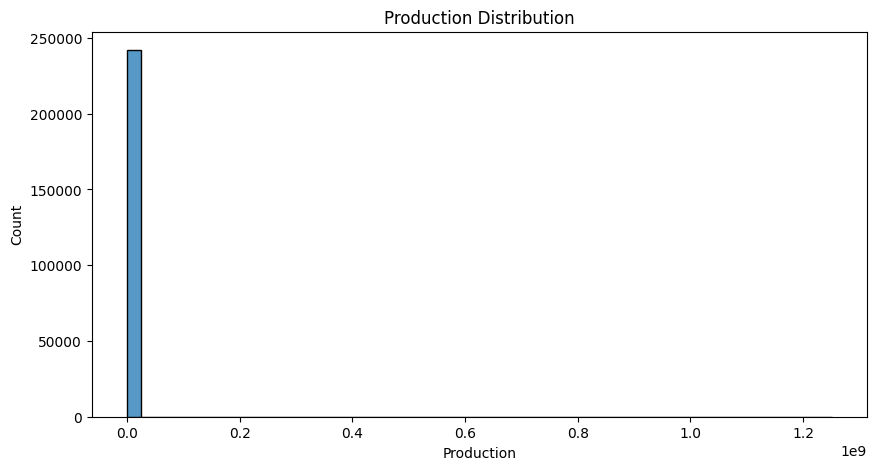

count    2.423610e+05
mean     5.825034e+05
std      1.706581e+07
min      0.000000e+00
25%      8.800000e+01
50%      7.290000e+02
75%      7.023000e+03
max      1.250800e+09
Name: Production, dtype: float64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['Production'], bins=50)
plt.title("Production Distribution")
plt.show()

print(df['Production'].describe())

In [13]:
top_crops = df.groupby('Crop')['Production'].sum().sort_values(ascending=False).head(10)
print(top_crops)

Crop
Coconut         1.299816e+11
Sugarcane       5.535682e+09
Rice            1.605470e+09
Wheat           1.332826e+09
Potato          4.248263e+08
Cotton(lint)    2.970000e+08
Maize           2.733418e+08
Jute            1.815582e+08
Banana          1.461327e+08
Soyabean        1.418372e+08
Name: Production, dtype: float64


In [14]:
top_states = df.groupby('State_Name')['Production'].sum().sort_values(ascending=False).head(10)
print(top_states)

State_Name
Kerala                         9.788005e+10
Andhra Pradesh                 1.732459e+10
Tamil Nadu                     1.207644e+10
Uttar Pradesh                  3.234493e+09
Assam                          2.111752e+09
West Bengal                    1.397904e+09
Maharashtra                    1.263641e+09
Karnataka                      8.634298e+08
Andaman and Nicobar Islands    7.182232e+08
Punjab                         5.863850e+08
Name: Production, dtype: float64


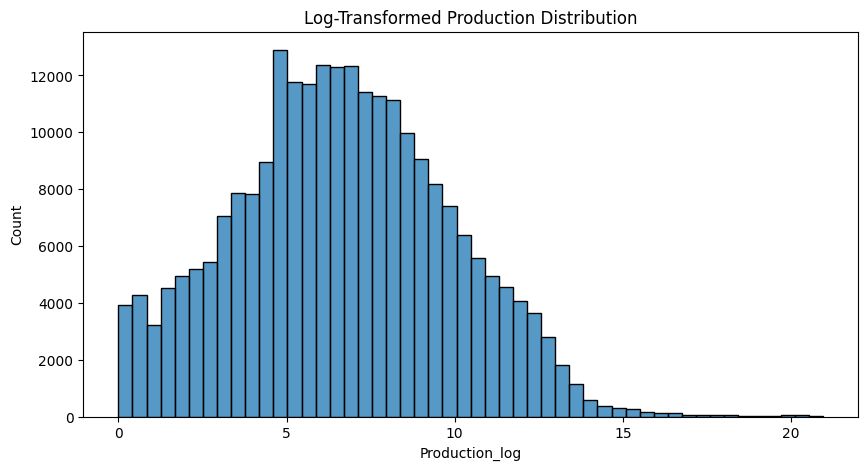

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df['Production_log'] = np.log1p(df['Production'])

plt.figure(figsize=(10,5))
sns.histplot(df['Production_log'], bins=50)
plt.title("Log-Transformed Production Distribution")
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder

le_state = LabelEncoder()
le_district = LabelEncoder()
le_season = LabelEncoder()
le_crop = LabelEncoder()

df['State_encoded'] = le_state.fit_transform(df['State_Name'])
df['District_encoded'] = le_district.fit_transform(df['District_Name'])
df['Season_encoded'] = le_season.fit_transform(df['Season'])
df['Crop_encoded'] = le_crop.fit_transform(df['Crop'])

df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Production_log,State_encoded,District_encoded,Season_encoded,Crop_encoded
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,7.601402,0,427,1,2
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.693147,0,427,1,74
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,5.774552,0,427,1,95
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,6.464588,0,427,4,7
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,5.111988,0,427,4,22


In [17]:
# Features aur target define karo
X = df[['State_encoded', 'District_encoded', 'Crop_Year', 'Season_encoded', 'Crop_encoded', 'Area']]
y = df['Production_log']   # log-transformed target use kar rahe hain

print(X.shape, y.shape)
X.head()

(242361, 6) (242361,)


,State_encoded,District_encoded,Crop_Year,Season_encoded,Crop_encoded,Area
0,0,427,2000,1,2,1254.0
1,0,427,2000,1,74,2.0
2,0,427,2000,1,95,102.0
3,0,427,2000,4,7,176.0
4,0,427,2000,4,22,720.0


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (169652, 6)
Validation shape: (36354, 6)
Test shape: (36355, 6)


In [19]:
!pip install xgboost -q

In [20]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [21]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

val_preds = xgb_model.predict(X_val)

r2 = r2_score(y_val, val_preds)
mae = mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))

print("Validation R² Score:", r2)
print("Validation MAE:", mae)
print("Validation RMSE:", rmse)

Validation R² Score: 0.9580591536743965
Validation MAE: 0.4273223525999843
Validation RMSE: 0.656010653297582


In [22]:
test_preds = xgb_model.predict(X_test)

r2_test = r2_score(y_test, test_preds)
mae_test = mean_absolute_error(y_test, test_preds)
rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))

print("Test R² Score:", r2_test)
print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)

Test R² Score: 0.9589579864281053
Test MAE: 0.42478109386163126
Test RMSE: 0.6525643267071844


In [23]:
import joblib

joblib.dump(xgb_model, 'crop_yield_model.pkl')
joblib.dump(le_state, 'le_state.pkl')
joblib.dump(le_district, 'le_district.pkl')
joblib.dump(le_season, 'le_season.pkl')
joblib.dump(le_crop, 'le_crop.pkl')

print("Model aur sabhi encoders save ho gaye!")

Model aur sabhi encoders save ho gaye!


In [31]:
import shutil
shutil.make_archive('yield_model_files', 'zip', '.', )

RuntimeError: File size too large, try using force_zip64

In [32]:
import os
import shutil

# Naya folder banao
os.makedirs('model_package', exist_ok=True)

# Sirf zaroori files copy karo
files_to_zip = ['crop_yield_model.pkl', 'le_state.pkl', 'le_district.pkl', 'le_season.pkl', 'le_crop.pkl']
for f in files_to_zip:
    shutil.copy(f, 'model_package/')

# Sirf is chhote folder ko zip karo
shutil.make_archive('model_package', 'zip', 'model_package')

print("Zip file ban gayi: model_package.zip")

Zip file ban gayi: model_package.zip


In [36]:
from google.colab import files
files.download('model_package.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>